# Quantitative image analysis
After segmenting and labeling objects in an image, we can measure properties of these objects.

See also
* [SciPy lecture notes: Measuring region properties](https://scipy-lectures.org/packages/scikit-image/index.html#measuring-regions-properties)
* [Plot regionprops](https://scikit-image.org/docs/stable/auto_examples/segmentation/plot_regionprops.html)

Before we can do measurements, we need an `image` and a corresponding `label_image`. Therefore, we recapitulate filtering, thresholding and labeling:

In [1]:
from skimage.io import imread
from skimage import filters
from skimage import measure
import pandas as pd
import numpy as np
import stackview

[[0 0 0 ... 5 5 5]
 [0 0 0 ... 5 5 5]
 [0 0 0 ... 5 5 5]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]
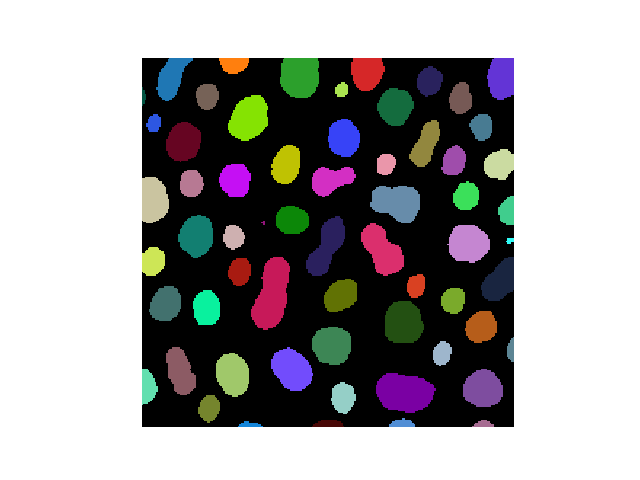

In [2]:
# load image
image = imread("data/blobs.tif")

# denoising
blurred_image = filters.gaussian(image, sigma=1)

# binarization
threshold = filters.threshold_otsu(blurred_image)
thresholded_image = blurred_image >= threshold

# labeling
label_image = measure.label(thresholded_image)

# visualization
stackview.insight(label_image)

## Measurements / region properties
To read out properties from regions, we use the [`regionprops_table`](https://scikit-image.org/docs/stable/api/skimage.measure.html#skimage.measure.regionprops_table) function, which directly returns a dictionary that can be converted to a pandas DataFrame:

In [3]:
# analyse objects using regionprops_table
properties = ['label', 'area', 'mean_intensity', 'major_axis_length', 'minor_axis_length']

measurements = measure.regionprops_table(label_image, intensity_image=image, properties=properties)

df = pd.DataFrame(measurements)
df.head()

,label,area,mean_intensity,major_axis_length,minor_axis_length
0,1,429.0,191.440559,34.779230,16.654732
1,2,183.0,179.846995,20.950530,11.755645
2,3,658.0,205.604863,30.198484,28.282790
3,4,433.0,217.515012,24.508791,23.079220
4,5,472.0,213.033898,31.084766,19.681190


The result is already a dictionary of arrays, which can directly be used as a pandas DataFrame. The properties available are listed in the [documentation of the `measure.regionprops` function](https://scikit-image.org/docs/dev/api/skimage.measure.html#skimage.measure.regionprops).

We can add custom columns, for example the `aspect_ratio`:

In [4]:
# add aspect_ratio column
df['aspect_ratio'] = df['major_axis_length'] / df['minor_axis_length']

df.head()

,label,area,mean_intensity,major_axis_length,minor_axis_length,aspect_ratio
0,1,429.0,191.440559,34.779230,16.654732,2.088249
1,2,183.0,179.846995,20.950530,11.755645,1.782168
2,3,658.0,205.604863,30.198484,28.282790,1.067734
3,4,433.0,217.515012,24.508791,23.079220,1.061942
4,5,472.0,213.033898,31.084766,19.681190,1.579415


Those dataframes can be saved to disk conveniently:

In [5]:
df.to_csv("blobs_analysis.csv")

Furthermore, one can measure properties from our `df` table using [numpy](https://numpy.org/doc/stable/). For example the mean area:

In [6]:
# measure mean area
np.mean(df['area'])

np.float64(355.3709677419355)

## Exercises
Analyse the loaded blobs `image`.

* How many objects are in it?

* How large is the largest object?

* What are mean and standard deviation of the image?

* What are mean and standard deviation of the area of the segmented objects?